In [2]:
import os
import json
import gymnasium as gym
import numpy as np
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.callbacks import BaseCallback, EvalCallback, CheckpointCallback

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
SEED = 42
N_ENVS = 8
TOTAL_TIMESTEPS = 30_000_000

LOG_DIR = "./ppo_hardcore_stable/"
MODEL_DIR = os.path.join(LOG_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ===============================
# SCHEDULES
# ===============================
class EntropyAnnealingCallback(BaseCallback):
    """
    Linearly anneals entropy coefficient from initial_ent_coef to final_ent_coef
    over total_timesteps.
    """

    def __init__(
        self,
        initial_ent_coef: float,
        final_ent_coef: float,
        total_timesteps: int,
        verbose: int = 0,
    ):
        super().__init__(verbose)
        self.initial_ent_coef = initial_ent_coef
        self.final_ent_coef = final_ent_coef
        self.total_timesteps = total_timesteps

    def _on_step(self) -> bool:
        progress = min(self.num_timesteps / self.total_timesteps, 1.0)
        new_ent = (
            self.initial_ent_coef
            + progress * (self.final_ent_coef - self.initial_ent_coef)
        )

        self.model.ent_coef = float(new_ent)

        # Optional: log for TensorBoard
        self.logger.record("train/ent_coef", self.model.ent_coef)

        return True

def linear_schedule(start, end):
    def schedule(progress_remaining):
        return end + (start - end) * progress_remaining
    return schedule

entropy_callback = EntropyAnnealingCallback(
    initial_ent_coef=0.005,
    final_ent_coef=0.0,
    total_timesteps=TOTAL_TIMESTEPS,
)

LR_SCHEDULE = linear_schedule(2.5e-4, 5e-5)

# ===============================
# ENV HELPERS
# ===============================
def make_env(rank):
    def _init():
        env = gym.make(ENV_ID)
        env.reset(seed=SEED + rank)
        return env
    return _init

# ===============================
# TRAINING ENV
# ===============================
train_env = SubprocVecEnv([make_env(i) for i in range(N_ENVS)])
train_env = VecNormalize(
    train_env,
    norm_obs=True,
    norm_reward=True,
    gamma=0.99,
    clip_obs=10.0
)

# ===============================
# EVAL ENV
# ===============================
eval_env = SubprocVecEnv([make_env(1000 + i) for i in range(5)])
eval_env = VecNormalize(
    eval_env,
    norm_obs=True,
    norm_reward=False,
    training=False
)

# ===============================
# CALLBACKS
# ===============================
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(MODEL_DIR, "best"),
    log_path=os.path.join(LOG_DIR, "eval"),
    eval_freq=max(100_000 // N_ENVS, 1),
    n_eval_episodes=5,
    deterministic=True,
    verbose=1,
)

checkpoint_callback = CheckpointCallback(
    save_freq=max(1_000_000 // N_ENVS, 1),
    save_path=os.path.join(MODEL_DIR, "checkpoints"),
    name_prefix="ppo_hardcore",
    save_vecnormalize=True,
)

# ===============================
# MODEL
# ===============================
model = PPO(
    policy="MlpPolicy",
    env=train_env,
    device=DEVICE,
    seed=SEED,

    # Architecture
    policy_kwargs=dict(
        net_arch=dict(pi=[256, 256], vf=[256, 256]),
        activation_fn=torch.nn.Tanh,
        ortho_init=False,
    ),

    # PPO core
    learning_rate=LR_SCHEDULE,
    n_steps=2048,
    batch_size=1024,
    n_epochs=10,
    gamma=0.99,
    gae_lambda=0.95,

    # Stability fixes
    clip_range=0.2,
    ent_coef=0.005,
    vf_coef=0.5,
    max_grad_norm=0.5,

    # Exploration
    use_sde=True,
    sde_sample_freq=4,

    verbose=1,
)

# ===============================
# TRAIN
# ===============================
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=[eval_callback, checkpoint_callback, entropy_callback],
    progress_bar=True,
)

# ===============================
# SAVE FINAL
# ===============================
model.save(os.path.join(MODEL_DIR, "final_model"))
train_env.save(os.path.join(MODEL_DIR, "vec_normalize.pkl"))

metadata = {
    "env": ENV_ID,
    "total_timesteps": TOTAL_TIMESTEPS,
    "seed": SEED,
    "n_envs": N_ENVS,
    "device": DEVICE,
}

with open(os.path.join(LOG_DIR, "run_info.json"), "w") as f:
    json.dump(metadata, f, indent=2)

train_env.close()
eval_env.close()

print("✅ Training complete.")


Using device: cpu

Using cpu device

LiveError: Only one live display may be active at once

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize, SubprocVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback

# ===============================
# CONFIGURATION
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"
BASE_LOG_DIR = "./arch_sweep/"
MODEL_NAME = "medium_256"
ADDITIONAL_TIMESTEPS = 10_000_000
N_ENVS = 8
SEED = 42

MODEL_DIR = os.path.join(BASE_LOG_DIR, MODEL_NAME, "continued_training")
BEST_MODEL_PATH = os.path.join(MODEL_DIR, "best_model", "best_model.zip")
FINAL_MODEL_PATH = os.path.join(MODEL_DIR, "final_model.zip")
VEC_NORMALIZE_PATH = os.path.join(MODEL_DIR, "vec_normalize.pkl")
CONTINUED_DIR = "Hope_2"

os.makedirs(CONTINUED_DIR, exist_ok=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

# ===============================
# HELPERS
# ===============================
def linear_schedule(initial_lr: float, min_lr: float = 5e-5):
    def func(progress_remaining: float):
        return max(progress_remaining * initial_lr, min_lr)
    return func

def make_env_with_unique_seed(env_id: str, rank: int, seed: int = 0):
    def _init():
        env = gym.make(env_id)
        env.reset(seed=seed + rank)
        return env
    return _init

def reset_rms(rms):
    # Works for both scalar and vector RMS
    if np.isscalar(rms.mean):
        rms.mean = 0.0
        rms.var = 1.0
    else:
        rms.mean[:] = 0.0
        rms.var[:] = 1.0
    rms.count = 1e-4


# ---- Create vectorized training env ----
train_env = SubprocVecEnv([make_env_with_unique_seed(ENV_ID, i, SEED) for i in range(N_ENVS)])

# ---- Load or create VecNormalize ----
if os.path.exists(VEC_NORMALIZE_PATH):
    train_env = VecNormalize.load(VEC_NORMALIZE_PATH, train_env)
    train_env.training = True
    train_env.norm_reward = True
    
    reset_rms(train_env.obs_rms)
    # Reset reward normalization (if enabled)
    if train_env.norm_reward:
        reset_rms(train_env.ret_rms)
else:
    train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, gamma=0.99, clip_obs=10.0)

# ---- Create eval env ----
eval_env = SubprocVecEnv([make_env_with_unique_seed(ENV_ID, i, SEED + 1000) for i in range(5)])
if os.path.exists(VEC_NORMALIZE_PATH):
    eval_env = VecNormalize.load(VEC_NORMALIZE_PATH, eval_env)
    eval_env.training = False
    eval_env.norm_reward = False
else:
    eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, training=False)

# ===============================
# CALLBACKS
# ===============================
eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(CONTINUED_DIR, "best_model"),
    log_path=os.path.join(CONTINUED_DIR, "eval"),
    eval_freq=max(50_000 // N_ENVS, 1),
    deterministic=True,
    n_eval_episodes=5,
    verbose=0,
)

checkpoint_callback = CheckpointCallback(
    save_freq=max(1_000_000 // N_ENVS, 1),
    save_path=os.path.join(CONTINUED_DIR, "checkpoints"),
    name_prefix="model_checkpoint",
    save_replay_buffer=False,
    save_vecnormalize=True,
)

# ===============================
# LOAD MODEL
# ===============================
if os.path.exists(BEST_MODEL_PATH):
    model_path = BEST_MODEL_PATH
elif os.path.exists(FINAL_MODEL_PATH):
    model_path = FINAL_MODEL_PATH
else:
    raise FileNotFoundError(f"No model found for {MODEL_NAME}")

print(f"🤖 Loading model from {model_path}")
model = PPO.load(model_path, env=train_env, device=DEVICE)

# Reset optimizer and learning rate for continued training
model.learning_rate = linear_schedule(2.5e-4)
model.optimizer = torch.optim.Adam(model.policy.parameters(), lr=model.learning_rate(1.0))
print("Learning rate at start:", model.learning_rate(1.0))
print("Entropy coef:", model.ent_coef)
print("Clip range:", model.clip_range)


# ===============================
# CONTINUE TRAINING
# ===============================
initial_timesteps = getattr(model, "num_timesteps", 0)
print(f"Model already trained for {initial_timesteps:,} timesteps")
target_timesteps = initial_timesteps + ADDITIONAL_TIMESTEPS
print(f"Training to {target_timesteps:,} timesteps...")

model.learn(
    total_timesteps=ADDITIONAL_TIMESTEPS,
    callback=[eval_callback, checkpoint_callback],
    reset_num_timesteps=False,
    progress_bar=True,
)

# ===============================
# SAVE MODEL AND ENV
# ===============================
final_model_path = os.path.join(CONTINUED_DIR, "final_model")
model.save(final_model_path)
train_env.save(os.path.join(CONTINUED_DIR, "vec_normalize.pkl"))

training_info = {
    "initial_model": model_path,
    "initial_timesteps": initial_timesteps,
    "additional_timesteps": ADDITIONAL_TIMESTEPS,
    "total_timesteps": model.num_timesteps,
}
with open(os.path.join(CONTINUED_DIR, "training_info.json"), "w") as f:
    json.dump(training_info, f, indent=2)

print(f"Model saved to {final_model_path}")
print(f"Total timesteps: {model.num_timesteps:,}")

train_env.close()
eval_env.close()


Using device: cpu


Output()

🤖 Loading model from ./arch_sweep/medium_256\continued_training\best_model\best_model.zip
Learning rate at start: 0.00025
Entropy coef: 0.005
Clip range: FloatSchedule(ConstantSchedule(val=0.25))
Model already trained for 10,840,000 timesteps
Training to 20,840,000 timesteps...


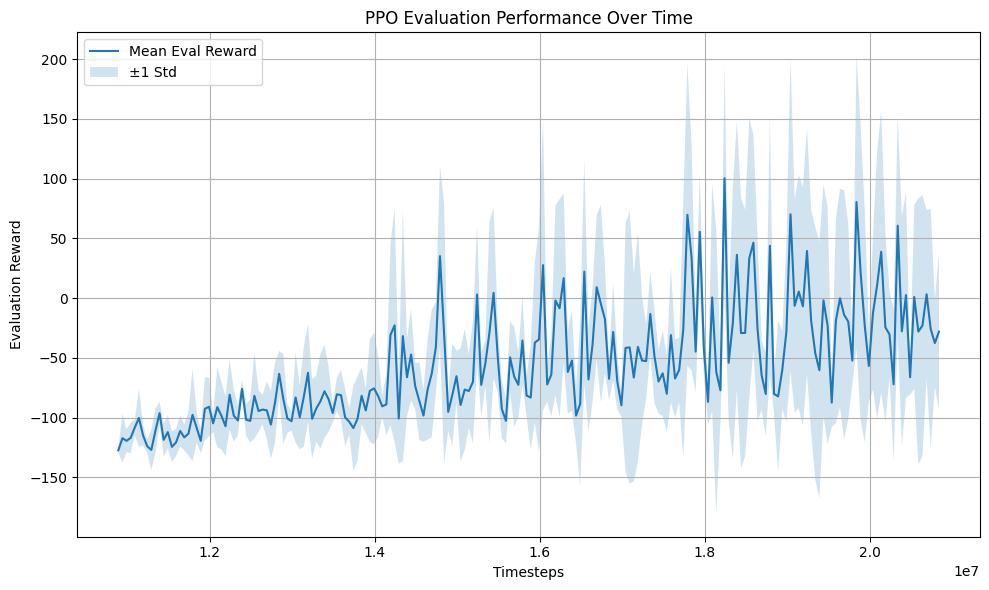

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

EVAL_FILE = "Hope/eval/evaluations.npz"

data = np.load(EVAL_FILE)

timesteps = data["timesteps"]
results = data["results"]

mean_rewards = results.mean(axis=1)
std_rewards = results.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(timesteps, mean_rewards, label="Mean Eval Reward")
plt.fill_between(
    timesteps,
    mean_rewards - std_rewards,
    mean_rewards + std_rewards,
    alpha=0.2,
    label="±1 Std"
)

plt.xlabel("Timesteps")
plt.ylabel("Evaluation Reward")
plt.title("PPO Evaluation Performance Over Time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [5]:
import os
import json
import torch
import numpy as np
import gymnasium as gym

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import VecNormalize, DummyVecEnv

# ===============================
# CONFIG
# ===============================
ENV_ID = "BipedalWalkerHardcore-v3"

MODEL_PATH = "./Hope/final_model.zip"          # change if needed
VEC_NORM_PATH = "./Hope/vec_normalize.pkl"     # optional but recommended
OUTPUT_JSON = "./Hope/model_diagnostics.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ===============================
# LOAD ENV (DUMMY, FOR SHAPES)
# ===============================
def make_env():
    return gym.make(ENV_ID)

env = DummyVecEnv([make_env])

if os.path.exists(VEC_NORM_PATH):
    env = VecNormalize.load(VEC_NORM_PATH, env)
    env.training = False
    env.norm_reward = False

# ===============================
# LOAD MODEL
# ===============================
print(f"Loading model from {MODEL_PATH}")
model = PPO.load(MODEL_PATH, env=env, device=DEVICE)

policy = model.policy

# ===============================
# EXTRACT INFORMATION
# ===============================
info = {}

# ---- General ----
info["device"] = DEVICE
info["algorithm"] = model.__class__.__name__
info["num_timesteps"] = int(model.num_timesteps)
info["seed"] = model.seed

# ---- Spaces ----
info["observation_space"] = str(env.observation_space)
info["action_space"] = str(env.action_space)

# ---- PPO Hyperparameters ----
info["ppo_hyperparameters"] = {
    "learning_rate": str(model.learning_rate),
    "n_steps": model.n_steps,
    "batch_size": model.batch_size,
    "n_epochs": model.n_epochs,
    "gamma": model.gamma,
    "gae_lambda": model.gae_lambda,
    "clip_range": str(model.clip_range),
    "clip_range_vf": model.clip_range_vf,
    "ent_coef": model.ent_coef,
    "vf_coef": model.vf_coef,
    "max_grad_norm": model.max_grad_norm,
    "target_kl": model.target_kl,
    "use_sde": model.use_sde,
    "sde_sample_freq": model.sde_sample_freq,
}

# ---- Policy Architecture ----
info["policy"] = {
    "policy_class": policy.__class__.__name__,
    "net_arch": policy.net_arch,
    "activation_fn": policy.activation_fn.__name__,
    "ortho_init": policy.ortho_init,
}

# ---- Network Sizes ----
def count_params(module):
    return sum(p.numel() for p in module.parameters())

info["network_params"] = {
    "total_params": count_params(policy),
    "actor_params": count_params(policy.mlp_extractor.policy_net),
    "critic_params": count_params(policy.mlp_extractor.value_net),
}

# ---- Optimizer ----
optimizer = model.optimizer
info["optimizer"] = {
    "type": optimizer.__class__.__name__,
    "lr": optimizer.param_groups[0]["lr"],
    "betas": optimizer.param_groups[0].get("betas", None),
    "eps": optimizer.param_groups[0].get("eps", None),
    "weight_decay": optimizer.param_groups[0].get("weight_decay", None),
}

# ---- VecNormalize Stats ----
if isinstance(env, VecNormalize):
    info["vecnormalize"] = {
        "norm_obs": env.norm_obs,
        "norm_reward": env.norm_reward,
        "clip_obs": env.clip_obs,
        "gamma": env.gamma,
        "obs_rms_mean": env.obs_rms.mean.tolist(),
        "obs_rms_var": env.obs_rms.var.tolist(),
        "ret_rms_mean": float(env.ret_rms.mean),
        "ret_rms_var": float(env.ret_rms.var),
        "count": float(env.ret_rms.count),
    }
else:
    info["vecnormalize"] = None

# ---- Action Distribution ----
dist = policy.action_dist
info["action_distribution"] = dist.__class__.__name__

# ===============================
# SAVE TO JSON
# ===============================
with open(OUTPUT_JSON, "w") as f:
    json.dump(info, f, indent=2)

# ===============================
# PRINT SUMMARY
# ===============================
print("\n===== MODEL SUMMARY =====")
print(f"Algorithm        : {info['algorithm']}")
print(f"Timesteps        : {info['num_timesteps']:,}")
print(f"Device           : {info['device']}")
print(f"Policy           : {info['policy']['policy_class']}")
print(f"Net Arch         : {info['policy']['net_arch']}")
print(f"Total Params     : {info['network_params']['total_params']:,}")
print(f"Entropy Coef     : {info['ppo_hyperparameters']['ent_coef']}")
print(f"Clip Range       : {info['ppo_hyperparameters']['clip_range']}")
print(f"Learning Rate    : {info['optimizer']['lr']}")
print("=========================\n")

print(f"📄 Full diagnostics saved to {OUTPUT_JSON}")


Loading model from ./Hope/final_model.zip

===== MODEL SUMMARY =====
Algorithm        : PPO
Timesteps        : 20,850,624
Device           : cpu
Policy           : ActorCriticPolicy
Net Arch         : {'pi': [256, 256], 'vf': [256, 256]}
Total Params     : 146,693
Entropy Coef     : 0.005
Clip Range       : FloatSchedule(ConstantSchedule(val=0.25))
Learning Rate    : 0.00025

📄 Full diagnostics saved to ./Hope/model_diagnostics.json


d:\Users\draar\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.BytesIO(b))